# Are You Actually an Introvert? The Big Five Data Has Thoughts.

If you spend any time on personality forums or social media, you would think most people are introverted, anxious, and deeply misunderstood. INFP and INTJ are practically aesthetic identities at this point.

But I got hold of two datasets: 19,719 real Big Five personality test responses from Open Psychometrics, plus an MBTI forum dataset of over 8,600 users, and what the data shows is very different from the online version of personality psychology.

The Big Five does not put you in a box. It measures five continuous traits: Extraversion, Neuroticism, Openness, Agreeableness, and Conscientiousness, scored 0 to 100. The science behind it is far more robust than the MBTI, which is why psychologists use it. So what do 19,000 real responses actually look like?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

op = pd.read_csv('openpsych_data.csv', sep='\t', on_bad_lines='skip')
TRAITS  = ['Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']
LETTERS = ['E', 'N', 'A', 'C', 'O']
COLORS  = ['#c0392b', '#2980b9', '#27ae60', '#d35400', '#8e44ad']

for trait, letter in zip(TRAITS, LETTERS):
    cols = [f'{letter}{i}' for i in range(1, 11)]
    op[trait] = (op[cols].mean(axis=1) - 1) / 4 * 100

mbti = pd.read_csv('mbti.csv')
cls  = pd.read_csv('class_big5_data.csv')
cls  = cls.rename(columns={'I': 'Extraversion', 'II': 'Neuroticism', 'III': 'Openness',
                            'IV': 'Agreeableness', 'V': 'Conscientiousness'})

print(f'Open Psychometrics: {len(op):,} respondents from {op["country"].nunique()} countries')
print(f'MBTI forum dataset: {len(mbti):,} users across {mbti["type"].nunique()} types')
print(f'Penn COMM 3180 class: {len(cls)} students')

Open Psychometrics: 19,719 respondents from 158 countries
MBTI forum dataset: 8,675 users across 16 types
Penn COMM 3180 class: 19 students


## The Internet Introvert Problem

Start with the MBTI data as it comes from an online personality forum, so the sample is self-selected. And the bias is stark.

Of the 8,675 users in the dataset, **77% are introverts**. The top three types are INFP (21%), INFJ (17%), and INTP (15%). Extraverted types barely appear.

This makes sense: introverts are more likely to join communities devoted to discussing personality. But it creates a massive distortion. If your only exposure to personality data is online forums, you would think introversion is the default. The actual data says otherwise.

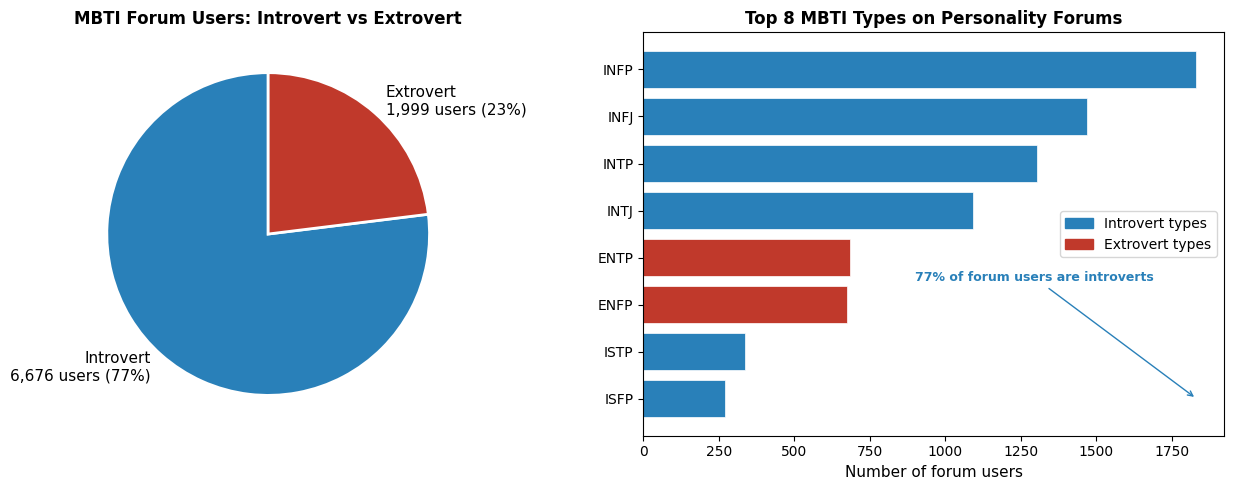

In [2]:
mbti['I_or_E'] = mbti['type'].str[0]
ie_counts = mbti['I_or_E'].value_counts()
top_types = mbti['type'].value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pie_labels = []
for l, v in zip(ie_counts.index, ie_counts.values):
    label = 'Introvert' if l == 'I' else 'Extrovert'
    pie_labels.append(f'{label}\n{v:,} users ({v/len(mbti)*100:.0f}%)')

axes[0].pie(ie_counts.values, labels=pie_labels, colors=['#2980b9', '#c0392b'],
            startangle=90, textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('MBTI Forum Users: Introvert vs Extrovert', fontsize=12, fontweight='bold')

bar_colors = ['#2980b9' if t[0] == 'I' else '#c0392b' for t in top_types.index]
axes[1].barh(top_types.index[::-1], top_types.values[::-1],
             color=bar_colors[::-1], edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Number of forum users', fontsize=11)
axes[1].set_title('Top 8 MBTI Types on Personality Forums', fontsize=12, fontweight='bold')
axes[1].legend(handles=[
    mpatches.Patch(color='#2980b9', label='Introvert types'),
    mpatches.Patch(color='#c0392b', label='Extrovert types')
], fontsize=10)
axes[1].annotate('77% of forum users are introverts',
                 xy=(1832, 0), xytext=(900, 2.5), fontsize=9,
                 color='#2980b9', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#2980b9'))
plt.tight_layout()
plt.show()

## What 19,000 Real Responses Actually Look Like

Now look at the Open Psychometrics Big Five data. Global averages for all five traits cluster between 52 and 58 out of 100. Nobody is dramatically off the charts.

Conscientiousness scores highest globally at 58. Extraversion and Neuroticism sit right around 52, so the population is nearly split down the middle on both. The one real gender gap is in Neuroticism: women score about 5 points higher than men, the largest consistent difference across all five traits.

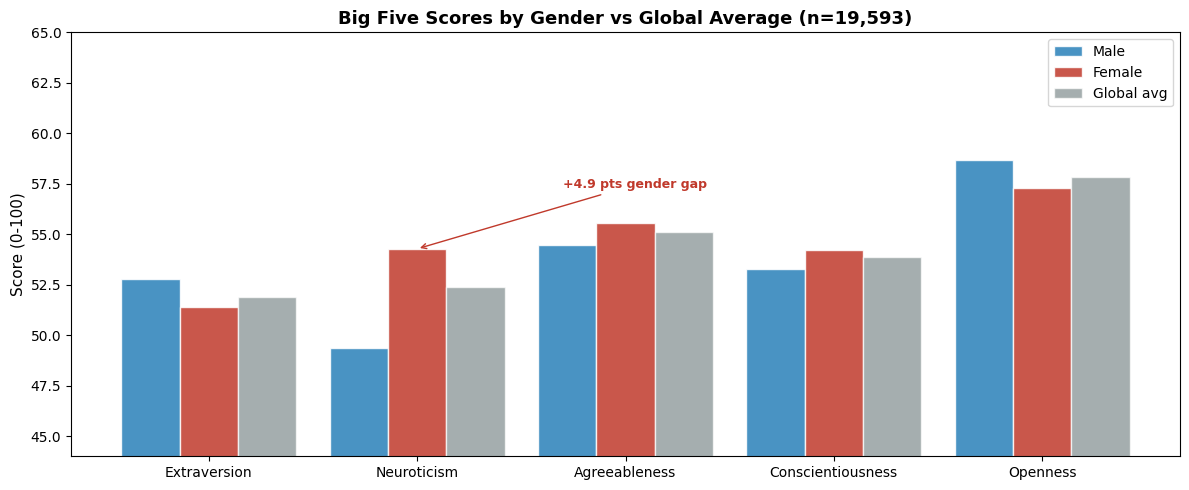

In [3]:
gd = op[op['gender'].isin([1, 2])].copy()
gd['gender_label'] = gd['gender'].map({1: 'Male', 2: 'Female'})
gender_means = gd.groupby('gender_label')[TRAITS].mean()
global_means = op[TRAITS].mean()

x = np.arange(len(TRAITS))
width = 0.28
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, gender_means.loc['Male'],   width, label='Male',       color='#2980b9', alpha=0.85, edgecolor='white')
ax.bar(x,         gender_means.loc['Female'], width, label='Female',     color='#c0392b', alpha=0.85, edgecolor='white')
ax.bar(x + width, global_means,               width, label='Global avg', color='#7f8c8d', alpha=0.70, edgecolor='white')

n_idx = TRAITS.index('Neuroticism')
gap = gender_means.loc['Female', 'Neuroticism'] - gender_means.loc['Male', 'Neuroticism']
ax.annotate(f'+{gap:.1f} pts gender gap',
            xy=(n_idx, gender_means.loc['Female', 'Neuroticism']),
            xytext=(n_idx + 0.7, gender_means.loc['Female', 'Neuroticism'] + 3),
            fontsize=9, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b'))
ax.set_xticks(x)
ax.set_xticklabels(TRAITS, fontsize=10)
ax.set_ylabel('Score (0-100)', fontsize=11)
ax.set_ylim(44, 65)
ax.set_title('Big Five Scores by Gender vs Global Average (n=19,593)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## The Older You Get, The Calmer You Become

This was the most striking finding. Neuroticism drops consistently as people age, from around 55 for teenagers to 44 for people in their 50s and 60s. That is an 11-point decline across a lifetime.

Meanwhile, Openness, Conscientiousness, Agreeableness, and Extraversion barely budge. The one thing that genuinely changes as you get older is how emotionally reactive you are, and it reliably goes down.

If you are 20 and feel more anxious than you would like, the data suggests that is both completely normal and, according to the trajectory of 19,000 people before you, temporary.

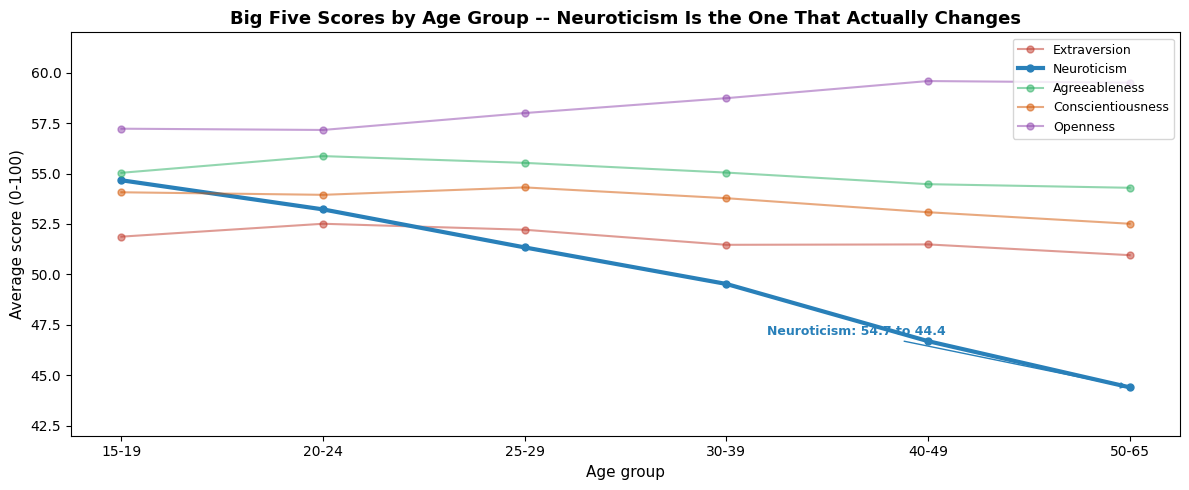

In [4]:
op2 = op[op['age'].between(15, 65)].copy()
op2['age_group'] = pd.cut(op2['age'], bins=[15, 20, 25, 30, 40, 50, 65],
                          labels=['15-19', '20-24', '25-29', '30-39', '40-49', '50-65'])
age_means = op2.groupby('age_group')[TRAITS].mean()

fig, ax = plt.subplots(figsize=(12, 5))
for trait, color in zip(TRAITS, COLORS):
    lw    = 3.0 if trait == 'Neuroticism' else 1.5
    alpha = 1.0 if trait == 'Neuroticism' else 0.5
    ax.plot(range(len(age_means)), age_means[trait], marker='o', markersize=5,
            label=trait, color=color, linewidth=lw, alpha=alpha)

neuro_start = age_means['Neuroticism'].iloc[0]
neuro_end   = age_means['Neuroticism'].iloc[-1]
ax.annotate(f'Neuroticism: {neuro_start:.1f} to {neuro_end:.1f}',
            xy=(5, neuro_end), xytext=(3.2, 47.0),
            fontsize=9, color='#2980b9', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2980b9'))
ax.set_xticks(range(len(age_means)))
ax.set_xticklabels(age_means.index, fontsize=10)
ax.set_xlabel('Age group', fontsize=11)
ax.set_ylabel('Average score (0-100)', fontsize=11)
ax.set_title('Big Five Scores by Age Group -- Neuroticism Is the One That Actually Changes',
             fontsize=13, fontweight='bold')
ax.set_ylim(42, 62)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

## How Does a Penn Comm Class Compare to the World?

Our class of 19 students also took the Big Five. Compared to the global average, the class skews noticeably higher on Extraversion (67.9 vs 51.9) and Openness (66.1 vs 57.8).

That is not surprising as a class at a selective university probably selects for outgoing and curious people. But the spread within the class is wide: nearly 30-point standard deviation on Extraversion. The dots scattered over the class bars below show just how much individual variation hides inside a single average.

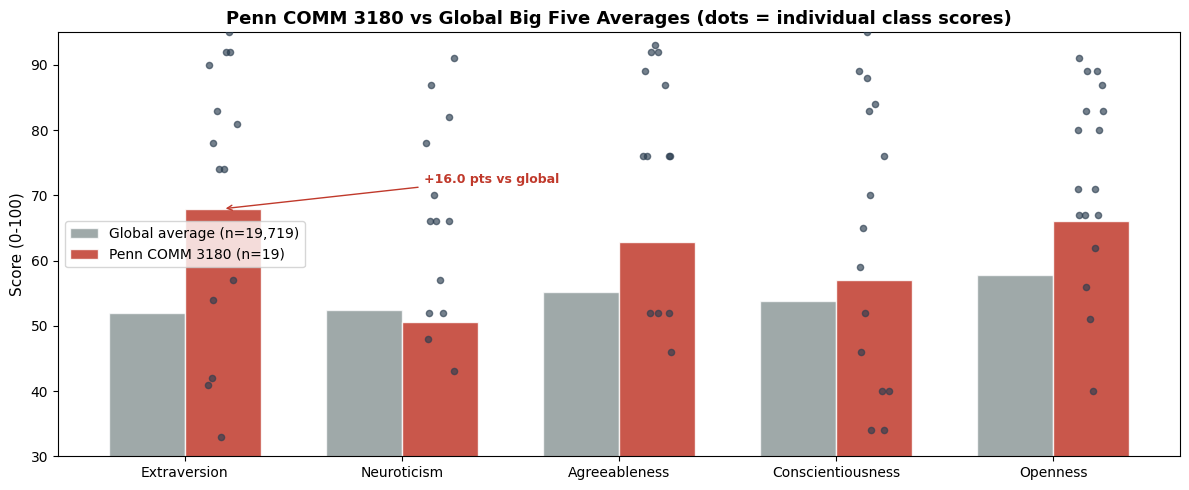

In [5]:
np.random.seed(42)
global_list = [op[t].mean() for t in TRAITS]
class_list  = [cls[t].mean() for t in TRAITS]

x = np.arange(len(TRAITS))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, global_list, width, label='Global average (n=19,719)',
       color='#7f8c8d', alpha=0.75, edgecolor='white')
ax.bar(x + width/2, class_list,  width, label='Penn COMM 3180 (n=19)',
       color='#c0392b', alpha=0.85, edgecolor='white')

e_idx = TRAITS.index('Extraversion')
gap_e = class_list[e_idx] - global_list[e_idx]
ax.annotate(f'+{gap_e:.1f} pts vs global',
            xy=(e_idx + width/2, class_list[e_idx]),
            xytext=(e_idx + 1.1, class_list[e_idx] + 4),
            fontsize=9, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b'))

for i, trait in enumerate(TRAITS):
    jitter = np.random.uniform(-0.07, 0.07, len(cls))
    ax.scatter([i + width/2 + j for j in jitter], cls[trait].values,
               color='#2c3e50', s=20, alpha=0.65, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(TRAITS, fontsize=10)
ax.set_ylabel('Score (0-100)', fontsize=11)
ax.set_ylim(30, 95)
ax.set_title('Penn COMM 3180 vs Global Big Five Averages (dots = individual class scores)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Conclusion

The data pushes back against the popular internet version of personality psychology on three fronts.

The introvert majority is an artifact of who uses personality forums online, not a reflection of the actual population. Globally, Extraversion sits at 52 out of 100, the population is nearly split down the middle.

The one personality trait that genuinely shifts over a lifetime is Neuroticism, and it goes down. The emotional reactivity that feels defining in your teens and twenties reliably softens by middle age. Everything else stays largely stable.

And a Penn communications class is measurably more extraverted and open than the global baseline, by 16 points on Extraversion. Whether that reflects who chooses communications, who gets into Penn, or just the noise of a 19-person sample, the gap is real.

Personality tests are more interesting when you compare yourself to 19,000 other people rather than to a description on a website. The data does not put you in a box. It puts you on a spectrum, and most people land much closer to the middle than the internet would have you believe.